# Analysis

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib notebook

In [2]:
import os
import sys
import glob
import scipy
import numpy as np
import pandas as pd
import scipy as sp
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.optimize import curve_fit
from matplotlib import patches
from matplotlib.ticker import FuncFormatter
from astropy import units as u
from astropy.coordinates import SkyCoord
from pathlib import Path
from tqdm import tqdm 

# PlatoSim libraries
import platosim.plot       as pt
import platosim.noise      as ns
import platosim.utilities  as ut
import platosim.statistics as st
from platosim.simfile      import SimFile
from platosim.simulation   import Simulation
from platosim.lightcurve   import LightCurve
from platosim.matplotlibrc import setup_paper
setup_paper()

import warnings
warnings.simplefilter("ignore")

In [3]:
# Define paths used throughout
fdir = '/lhome/nicholas/Nextcloud/paperMOCKA/figures'

---
## Compare input and output
---

In [4]:
# Load star results
star = f'{1}'.zfill(9)
path = '/lhome/nicholas/software/workdir/mocka_affogato'
dp = pd.read_feather(f'{path}/varsource/{star}/varsource_001_parameters.ftr')
df = pd.read_feather(f'{path}/varsource/{star}/varsource_001_pulsations.ftr')
dm = pd.read_feather(f'{path}/test_final/modes/modes_{star}.ftr')

# Correct for gamma factor
df.ampl *= 2.2

# Convert dmag to ppm
df.ampl = (1 - ut.fromMagToFlux(df.ampl)) * 1e6

# Fetch input frequencies in pettern
f_i = 1 / np.array([dp.DeltaP0_day * ((1 + dp.slope)**i - 1)/dp.slope + dp.P0_day for i in range(dp.N_modes[0])])

# Get pattern
dex_df = np.array([ut.findNearestIndex(df.freq, f_i[i]) for i in range(dp.N_modes[0])])
dex_dm = np.array([ut.findNearestIndex(dm.freq, f_i[i]) for i in range(dp.N_modes[0])])
df0 = df.loc[dex_df].reset_index(drop=True)
dm0 = dm.loc[dex_dm].reset_index(drop=True)

# O-C plot
f_oc = df0.freq.to_numpy() - dm0.freq.to_numpy()
A_oc = df0.ampl.to_numpy() - dm0.ampl.to_numpy()

dm1 = dm[dm.passed_snr]

# Remove matches above 0.01 c/d in the OC diagram
x = 0.0005
dex = np.where((np.abs(f_oc) > x))[0]
dm0 = dm0.drop(index=dex)
f0_oc = np.delete(f_oc, dex)
A0_oc = np.delete(A_oc, dex)

print(f'Stellar magnitude  : {dp.Pmag[0]:.4f} mag')
print(f'Limiting amplitude : {dm.ampl.min():.4f} ppm')
print(f'Number of modes    : {dm0.shape[0]}/{dp.N_modes[0]}')
print(f'RMS O-C amplitude  : {ut.rootMeanSquare(A0_oc):.4f} ppm')
print(f'RMS O-C frequency  : {ut.rootMeanSquare(f0_oc)*1e6:.4f} ppm/d')

Stellar magnitude  : 13.9368 mag
Limiting amplitude : 43.9185 ppm
Number of modes    : 13/16
RMS O-C amplitude  : 481.3366 ppm
RMS O-C frequency  : 142.3186 ppm/d


<IPython.core.display.Javascript object>


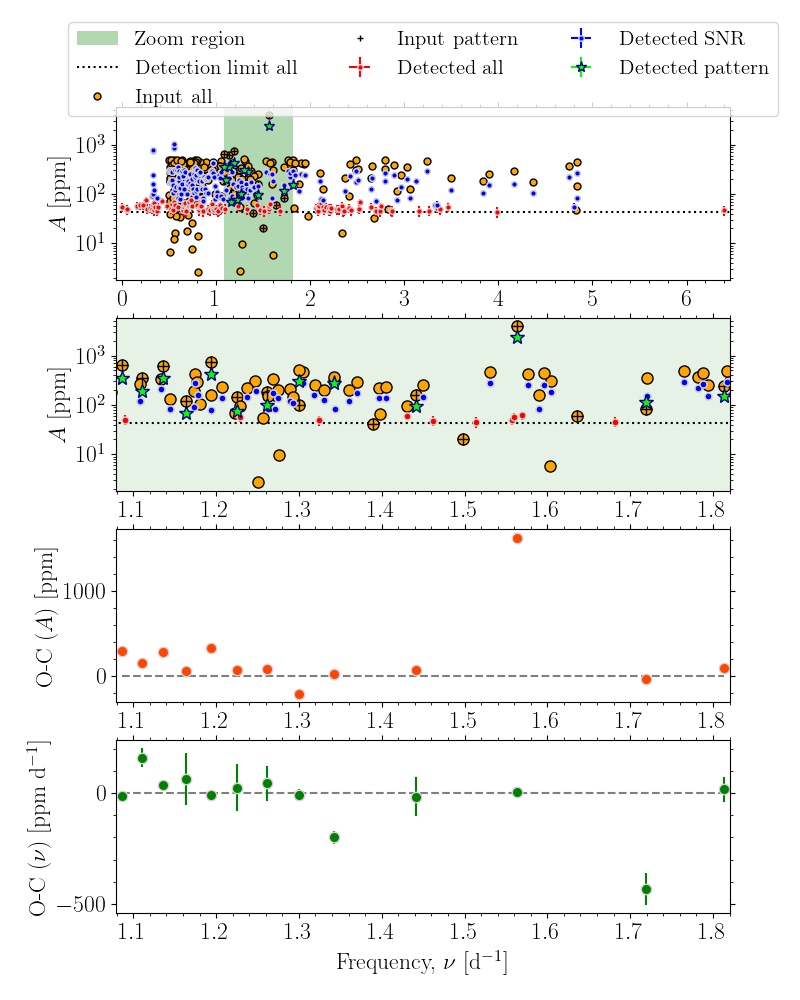

In [5]:
fig, ax = plt.subplots(4, 1, figsize=(8,10))

xlim0 = pt.getAxesMinMax(x=dm.freq.to_numpy(),  percentage=1)
xlim1 = pt.getAxesMinMax(x=dm0.freq.to_numpy(), percentage=1)

ax[0].axvspan(df0.freq.min(), df0.freq.max(), color='g', alpha=0.3, lw=0, label='Zoom region')
# ax[0].axvline(x=1/(ut.quarter()), ls='--', c='m', label='Quarter')
# ax[0].axvline(x=1/(ut.quarter()/3), ls=':', c='m', label='Mask-update')
ax[0].axhline(y=dm.ampl.min(), xmin=xlim0[1], xmax=xlim0[0], ls=':', c='k', label='Detection limit all')
ax[0].plot(df.freq,  df.ampl,  'o', ms=5, c='orange', mec='k', label='Input all')
ax[0].plot(df0.freq, df0.ampl, '+', ms=5, c='k', label='Input pattern')
ax[0].errorbar(dm.freq,  dm.ampl,  xerr=dm.freq_err,  yerr=dm.ampl_err,  fmt=".", ms=8, mec='lightgray', color="red",  label='Detected all')
ax[0].errorbar(dm1.freq, dm1.ampl, xerr=dm1.freq_err, yerr=dm1.ampl_err, fmt=".", ms=8, mec='lightgray', color="blue", label='Detected SNR')
ax[0].errorbar(dm0.freq, dm0.ampl, xerr=dm0.freq_err, yerr=dm0.ampl_err, fmt="*", ms=8, mec='navy', color="lime", label='Detected pattern')
ax[0].legend(loc='upper center', ncol=3, bbox_to_anchor=(0.5, 1.55), fontsize=15)
ax[0].set_ylabel(r'$A$ [ppm]')
ax[0].set_yscale('log')
ax[0].set_xlim(xlim0)

ax[1].axvspan(xlim1[0], xlim1[1], color='g', alpha=0.1, lw=0)
ax[1].axhline(y=dm.ampl.min(), xmin=xlim0[0], xmax=xlim0[1], ls=':', c='k')
ax[1].plot(df.freq,  df.ampl,  'o', ms=8, c='orange', mec='k')
ax[1].plot(df0.freq, df0.ampl, '+', ms=8, c='k')
ax[1].errorbar(dm.freq,  dm.ampl,  xerr=dm.freq_err,  yerr=dm.ampl_err,  fmt=".", ms=10, mec='lightgray', color="red")
ax[1].errorbar(dm1.freq, dm1.ampl, xerr=dm1.freq_err, yerr=dm1.ampl_err, fmt=".", ms=10, mec='lightgray', color="blue")
ax[1].errorbar(dm0.freq, dm0.ampl, xerr=dm0.freq_err, yerr=dm0.ampl_err, fmt="*", ms=10, mec='navy', color="lime")
ax[1].set_ylabel(r'$A$ [ppm]')
ax[1].set_yscale('log')
ax[1].set_xlim(xlim1[1], xlim1[0])

ax[2].plot([df0.freq.min(), df0.freq.max()], [0, 0], 'k--', alpha=0.5)
ax[2].errorbar(dm0.freq, A0_oc, xerr=None, yerr=dm0.ampl_err, fmt=".", ms=15, mec='lightgray', color="orangered")
ax[2].set_ylabel(r'O-C ($A$) [ppm]')
ax[2].set_xlim(xlim1[1], xlim1[0])

ax[3].plot([df0.freq.min(), df0.freq.max()], [0, 0], 'k--', alpha=0.5)
ax[3].errorbar(dm0.freq, f0_oc*1e6, xerr=None, yerr=dm0.freq_err*1e6, fmt=".", ms=15, mec='lightgray', color="g")
ax[3].set_xlabel(r'Frequency, $\nu$ [d$^{-1}$]')
ax[3].set_ylabel(r'O-C ($\nu$) [ppm d$^{-1}$]')
ax[3].set_xlim(xlim1[1], xlim1[0])

plt.tight_layout(h_pad=0.1);
# fig.savefig(f'{fdir}/FrequencyModelComparison_test0.png', bbox_inches='tight', dpi=200)

In [ ]:
# fig, ax = plt.subplots(3, 1, figsize=(8,8))

# xlim0 = pt.getAxesMinMax(x=dm.freq.to_numpy(),  percentage=1)
# xlim1 = pt.getAxesMinMax(x=dm0.freq.to_numpy(), percentage=1)

# ax[0].axvspan(df0.freq.min(), df0.freq.max(), color='green', alpha=0.3, lw=0, label='Zoom region')
# ax[0].axhline(y=dm.ampl.min(), xmin=xlim0[1], xmax=xlim0[0], ls=':', c='k', label='Detection limit')
# ax[0].plot(df.freq,  df.ampl,  'o', ms=5, c='orange', mec='k', label='Input all')
# ax[0].plot(df0.freq, df0.ampl, '+', ms=5, c='k', label='Input pattern')
# ax[0].errorbar(dm.freq,  dm.ampl,  xerr=dm.freq_err,  yerr=dm.ampl_err,  fmt=".", ms=8, mec='lightgray', color="b", label='Detected all')
# ax[0].errorbar(dm0.freq, dm0.ampl, xerr=dm0.freq_err, yerr=dm0.ampl_err, fmt=".", ms=8, mec='lightgray', color="deeppink", label='Detected pattern')
# ax[0].legend(loc='upper center', ncol=3, bbox_to_anchor=(0.5, 1.55), fontsize=15)
# ax[0].set_ylabel(r'$A$ [ppm]')
# ax[0].set_yscale('log')
# ax[0].set_xlim(xlim0)

# ax[1].axvspan(xlim1[0], xlim1[1], color='green', alpha=0.1, lw=0)
# ax[1].axhline(y=dm.ampl.min(), xmin=xlim0[0], xmax=xlim0[1], ls=':', c='k')
# ax[1].plot(df.freq,  df.ampl,  'o', ms=8, c='orange', mec='k')
# ax[1].plot(df0.freq, df0.ampl, '+', ms=8, c='k')
# ax[1].errorbar(dm.freq,  dm.ampl,  xerr=dm.freq_err,  yerr=dm.ampl_err,  fmt=".", ms=10, mec='lightgray', color="b")
# ax[1].errorbar(dm0.freq, dm0.ampl, xerr=dm0.freq_err, yerr=dm0.ampl_err, fmt=".", ms=10, mec='lightgray', color="deeppink")
# ax[1].set_ylabel(r'$A$ [ppm]')
# ax[1].set_yscale('log')
# ax[1].set_xlim(xlim1[1], xlim1[0])

# ax[2].plot([df0.freq.min(), df0.freq.max()], [0, 0], 'k--', alpha=0.5)
# ax[2].errorbar(dm0.freq, f0_oc*1e4, xerr=None, yerr=dm0.freq_err*1e4, fmt=".", ms=15, mec='lightgray', color="g")
# ax[2].set_xlabel(r'Frequency, $\nu$ [d$^{-1}$]')
# ax[2].set_ylabel(r'O-C ($\nu$) [ppm d$^{-1}$]')
# ax[2].set_xlim(xlim1[1], xlim1[0])

# plt.tight_layout(h_pad=0.1);
# fig.savefig(f'{fdir}/FrequencyModelComparison_test0.png', bbox_inches='tight', dpi=200)

---
## Variable templates
---

In [ ]:
import natsort
# Load csv file
idir = '/lhome/nicholas/software/workdir/mocka/varsource'
odir = '/lhome/nicholas/software/workdir/mocka/varsource_feather'

folders = natsort.natsorted(glob.glob(f'{idir}/*'))
n = len(files) 

for i in tqdm(range(n), bar_format=ut.tqdmBar()):
    
    df = pd.read_csv(f'{folders[i]}/varsource_001.txt', sep=' ', names=['time', 'mag'])
    print(df)
    star = f'{i}'.zfill(9)
    ofolder = f'{odir}/{star}'
    os.mkdir()
    
    sys.exit()